<a href="https://colab.research.google.com/github/kediwudiko-commits/EMSC2010-Project-Notebook-and-Repository/blob/main/EMSC2010_Assessment_3_Individual_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Estimation of Extreme Rainfall Thresholds in South-Eastern Australia: A Comparison Across Climate Zones

**GitHub Repository:**

---

## 1. Problem Framing and Scope

### 1.1 Research Question

> *To what extent do the statistical properties and exceedance probabilities
> of annual maximum daily rainfall differ across coastal, inland, and
> transitional climate zones in south-eastern Australia?*

### 1.2 Scientific Motivation

Extreme rainfall events pose significant risks to infrastructure,
agriculture, and communities across south-eastern Australia.
Understanding how these risks vary across different climate zones
is critical for effective flood mitigation and water resource management.

Traditional approaches often rely on simple summary statistics,
which fail to capture the uncertainty surrounding rare, high-magnitude
events. This project applies a **Bayesian inference framework** to
quantify that uncertainty explicitly, producing not just point estimates
but full posterior probability distributions for key rainfall parameters.

The **Gumbel distribution** (Extreme Value Type I) is used to model
annual maximum daily rainfall, as it is specifically designed for
block maxima data and captures the right-skewed behaviour characteristic
of extreme precipitation events.

### 1.3 Station Selection

To capture the regional climate gradient of south-eastern Australia,
three long-term observation stations from the Australian Bureau of
Meteorology (BOM) are selected:

1. **Sydney (Observatory Hill - 066214):** Coastal climate, heavily
   influenced by maritime air masses and East Coast Lows.
2. **Canberra (Airport - 070351):** Inland/tableland climate,
   characterised by higher altitude and convective summer storms.
3. **Melbourne (Olympic Park - 086338):** Transitional southern climate,
   influenced by the Southern Ocean and frontal systems.

---

## 2. Data Ingestion and Preprocessing

### 2.1 Data Source

Daily rainfall records are obtained from the Australian Bureau of
Meteorology (BOM) for each station. Rainfall amounts are measured
in millimetres (mm).

### 2.2 Methodological Approach: Block Maxima

To model extreme events, the **Block Maxima method** is applied.
The daily time series is partitioned into annual blocks (calendar years),
and exactly one maximum value is extracted per year. This produces a
series of Annual Maximum Daily Rainfall (AMDR) values suitable for
extreme value modelling.

### 2.3 Data Cleaning Assumptions

- Rainfall values are converted to numeric format; non-numeric
  entries are treated as missing (NaN).
- Years with more than **10% missing daily records** (>36 days)
  are excluded to prevent underestimation of the true annual maximum.

---

## 3. Baseline Distribution Fitting (MLE)

### 3.1 Normal Distribution

As a baseline reference, a **Normal distribution** is fitted to
each station's AMDR series using Maximum Likelihood Estimation (MLE).
The Normal distribution is symmetric and does not account for the
heavy right tail typically observed in extreme rainfall data.

### 3.2 Gumbel Distribution

A **Gumbel distribution** (Extreme Value Type I) is also fitted
using MLE. Unlike the Normal distribution, the Gumbel is right-skewed
and is theoretically justified for modelling block maxima by
Extreme Value Theory. The two parameters are:

- **μ (location):** Controls the centre of the distribution
- **σ (scale):** Controls the spread of the distribution

### 3.3 Model Comparison

The Normal and Gumbel fits are visually compared against the
observed histogram for each station to justify the use of the
Gumbel distribution in the Bayesian model.

---

## 4. Bayesian Gumbel Model (PyMC)

### 4.1 Model Structure

A Bayesian model is constructed using **PyMC** with the following
components:

**Priors:**
- μ ~ Normal(mean=data mean, σ=20) — weakly informative,
  centred on the sample mean
- σ ~ HalfNormal(σ=15) — ensures positive scale parameter

**Likelihood:**
- Annual Max Rainfall ~ Gumbel(μ, σ)

### 4.2 Prior Justification

Weakly informative priors are chosen to let the data dominate
the posterior, while still regularising the sampler. The prior
for μ is centred on the sample mean from the MLE fit in Section 3,
reflecting our initial knowledge before formal inference.

### 4.3 MCMC Sampling

Posterior distributions are sampled using **Markov Chain Monte Carlo
(MCMC)** via PyMC:
- 2000 draws, 2000 tuning steps, 4 chains
- target_accept = 0.9 to improve sampler stability

Convergence is assessed visually using **trace plots** and
numerically using the **R-hat statistic** (values close to 1.0
indicate convergence).

---

## 5. Threshold Exceedance Probability

### 5.1 Exceedance Probability

Using the posterior samples of μ and σ, the probability of
annual maximum daily rainfall **exceeding 100 mm** is calculated
for each station. By propagating uncertainty through the full
posterior distribution, we obtain not just a point estimate but
a **credible interval** for this probability.

### 5.2 Return Period

The **return period** for a 150 mm rainfall event is estimated
for each station, again with full posterior uncertainty quantified
via 95% HDI.

---

## 6. Cross-Station Comparison and Conclusions

### 6.1 Comparison of Posterior Parameters

The posterior distributions of μ across the three stations are
compared to assess how the typical magnitude of annual maximum
rainfall differs by climate zone.

### 6.2 Exceedance Probability Curves

Exceedance probability curves are plotted across a range of
thresholds (50–250 mm) for all three stations, providing a
comprehensive picture of extreme rainfall risk by climate zone.

### 6.3 Summary Table

A final summary table consolidates the key results:
- Posterior μ and σ
- P(Annual Max > 100 mm)
- Return period for 150 mm events

### 6.4 Conclusions

*(To be completed after results are obtained)*

Key questions to address:
- Which climate zone has the highest extreme rainfall risk?
- How does uncertainty differ across stations?
- What are the limitations of this analysis?

---

## 7. Limitations and Future Work

- The **stationarity assumption** — the model assumes rainfall
  statistics do not change over time. In reality, climate change
  may be altering extreme rainfall patterns.
- **Short record lengths** for some stations may limit the
  reliability of tail estimates.
- Future work could incorporate a **non-stationary model** where
  μ varies as a function of time or climate indices (e.g. ENSO).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm
import arviz as az

In [2]:
def load_and_clean_bom(filepath, station_name):
    df = pd.read_csv(filepath)
    df = df.rename(columns={
        'Year': 'year',
        'Month': 'month',
        'Day': 'day',
        'Rainfall amount (millimetres)': 'rainfall',
        'Quality': 'quality'
    })
    df['station'] = station_name
    df['rainfall'] = pd.to_numeric(df['rainfall'], errors='coerce')
    return df[['year', 'month', 'day', 'rainfall', 'quality', 'station']]

sydney_daily    = load_and_clean_bom('Sydney daily rainfall data.csv',    'Sydney')
canberra_daily  = load_and_clean_bom('Canberra daily rainfall data.csv',  'Canberra')
melbourne_daily = load_and_clean_bom('Melbourne daily rainfall data.csv', 'Melbourne')

In [3]:
def clean_and_block_maxima(df, missing_threshold=0.10):
    yearly_stats = df.groupby('year')['rainfall'].agg(
        missing_days=lambda x: x.isna().sum()
    )
    bad_years = yearly_stats[
        yearly_stats['missing_days'] / 365 > missing_threshold
    ].index
    print(f"Excluded years (>10% missing): {list(bad_years)}")

    df_clean = df[~df['year'].isin(bad_years)]
    annual_max = df_clean.groupby('year')['rainfall'].max().dropna().reset_index()
    annual_max.columns = ['year', 'rainfall']
    return annual_max

print("--- Sydney ---")
sydney_max    = clean_and_block_maxima(sydney_daily)
print("--- Canberra ---")
canberra_max  = clean_and_block_maxima(canberra_daily)
print("--- Melbourne ---")
melbourne_max = clean_and_block_maxima(melbourne_daily)

--- Sydney ---
Excluded years (>10% missing): [2017]
--- Canberra ---
Excluded years (>10% missing): [2008]
--- Melbourne ---
Excluded years (>10% missing): [2013]


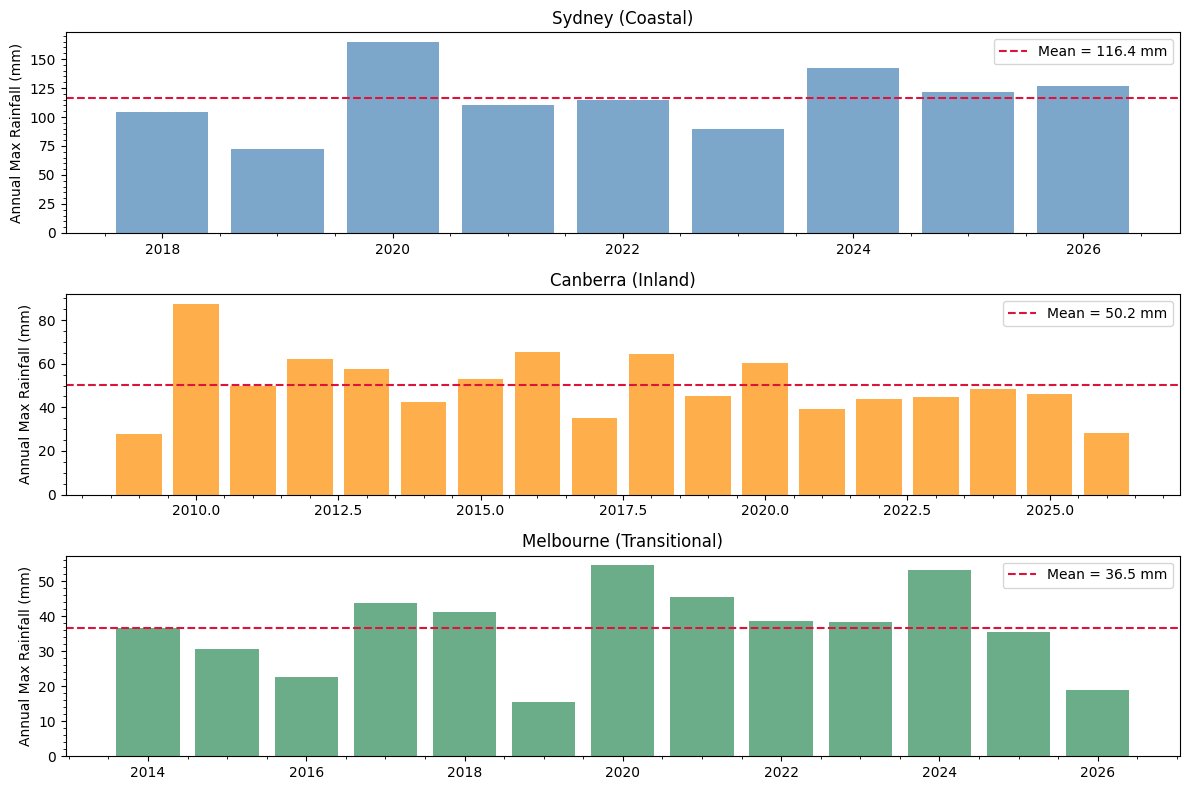

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for ax, data, color, title in zip(
    axes,
    [sydney_max, canberra_max, melbourne_max],
    ['steelblue', 'darkorange', 'seagreen'],
    ['Sydney (Coastal)', 'Canberra (Inland)', 'Melbourne (Transitional)']
):
    ax.bar(data['year'], data['rainfall'], color=color, alpha=0.7)
    ax.axhline(data['rainfall'].mean(), color='crimson',
               linestyle='--', lw=1.5,
               label=f"Mean = {data['rainfall'].mean():.1f} mm")
    ax.set_ylabel('Annual Max Rainfall (mm)')
    ax.set_title(title)
    ax.legend()
    ax.minorticks_on()

plt.tight_layout()
plt.show()

The Block Maxima method was applied to daily rainfall records from
three BOM stations. During data cleaning, years with more than 10%
missing daily records were identified and excluded:

- **Sydney:** 2017 excluded
- **Canberra:** 2008 excluded  
- **Melbourne:** 2013 excluded

The resulting Annual Maximum Daily Rainfall (AMDR) series shows
clear differences across climate zones. Sydney (Coastal) records
the highest annual maxima, with a historical mean of **116.4 mm**,
reflecting the influence of intense East Coast Low pressure systems
and orographic enhancement. Canberra (Inland) shows a moderate mean
of **50.2 mm**, driven primarily by convective summer storms.
Melbourne (Transitional) records the lowest mean of **36.5 mm**,
consistent with its frontal-dominated rainfall regime which tends
to produce more frequent but lower-intensity events.

The large year-to-year variability observed at all three stations —
particularly Sydney's range from ~70 mm to over 160 mm — highlights
the need for a probabilistic framework rather than simple
point estimates.

In [5]:
def fit_normal(annual_max_df, station_name):
    data = annual_max_df['rainfall'].values
    mu, sigma = stats.norm.fit(data)
    print(f"\n{station_name} Normal Fit:")
    print(f"  Mean (mu):       {mu:.2f} mm")
    print(f"  Std Dev (sigma): {sigma:.2f} mm")
    return mu, sigma

mu_syd, sigma_syd = fit_normal(sydney_max,    'Sydney')
mu_can, sigma_can = fit_normal(canberra_max,  'Canberra')
mu_mel, sigma_mel = fit_normal(melbourne_max, 'Melbourne')


Sydney Normal Fit:
  Mean (mu):       116.42 mm
  Std Dev (sigma): 25.79 mm

Canberra Normal Fit:
  Mean (mu):       50.16 mm
  Std Dev (sigma): 14.20 mm

Melbourne Normal Fit:
  Mean (mu):       36.52 mm
  Std Dev (sigma): 11.60 mm


In [6]:
def fit_gumbel(annual_max_df, station_name):
    data = annual_max_df['rainfall'].values
    mu_gum, sigma_gum = stats.gumbel_r.fit(data)
    print(f"\n{station_name} Gumbel Fit:")
    print(f"  Location (mu):  {mu_gum:.2f} mm")
    print(f"  Scale (sigma):  {sigma_gum:.2f} mm")
    return mu_gum, sigma_gum

mu_gum_syd, sigma_gum_syd = fit_gumbel(sydney_max,    'Sydney')
mu_gum_can, sigma_gum_can = fit_gumbel(canberra_max,  'Canberra')
mu_gum_mel, sigma_gum_mel = fit_gumbel(melbourne_max, 'Melbourne')


Sydney Gumbel Fit:
  Location (mu):  103.74 mm
  Scale (sigma):  23.67 mm

Canberra Gumbel Fit:
  Location (mu):  43.49 mm
  Scale (sigma):  11.99 mm

Melbourne Gumbel Fit:
  Location (mu):  30.57 mm
  Scale (sigma):  11.46 mm


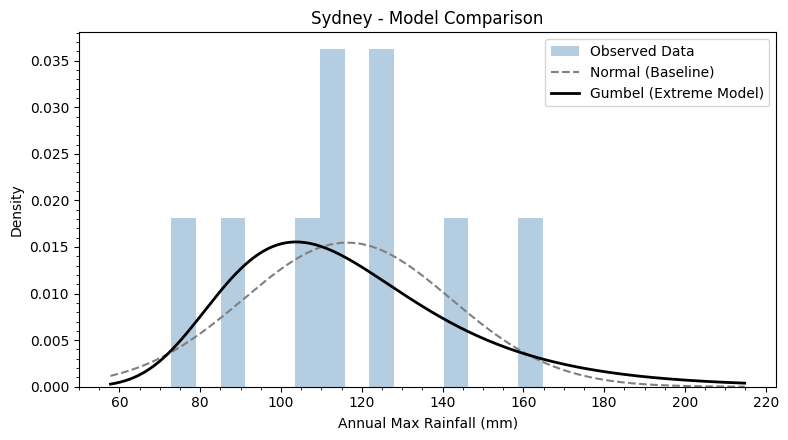

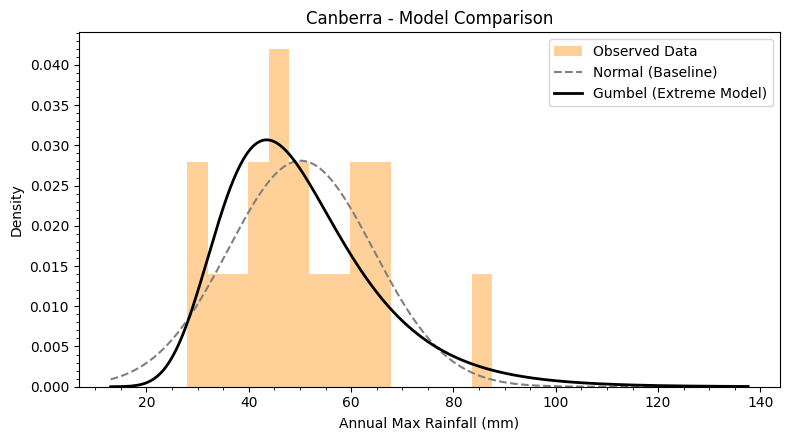

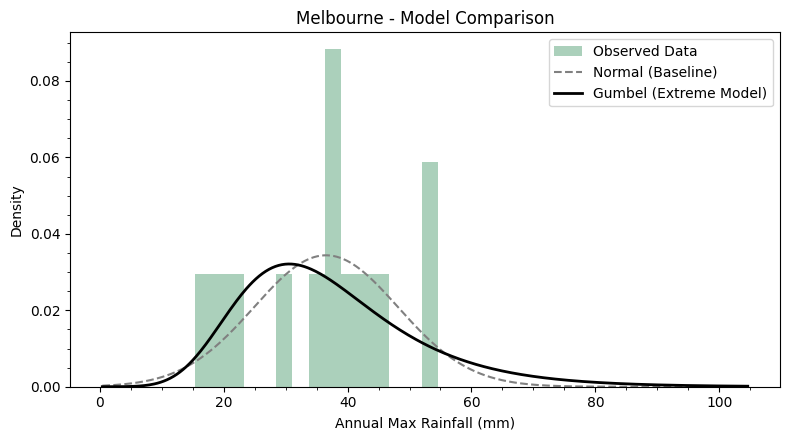

In [7]:
def plot_model_comparison(annual_max_df, norm_mu, norm_sigma,
                          gum_mu, gum_sigma, station_name, plot_color):
    data = annual_max_df['rainfall'].values
    x = np.linspace(data.min() - 15, data.max() + 50, 400)

    pdf_norm = stats.norm.pdf(x, loc=norm_mu, scale=norm_sigma)
    pdf_gum  = stats.gumbel_r.pdf(x, loc=gum_mu, scale=gum_sigma)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(data, bins=15, density=True,
            color=plot_color, alpha=0.4, label='Observed Data')
    ax.plot(x, pdf_norm, color='gray', lw=1.5,
            linestyle='--', label='Normal (Baseline)')
    ax.plot(x, pdf_gum,  color='black', lw=2,
            label='Gumbel (Extreme Model)')
    ax.set_xlabel('Annual Max Rainfall (mm)')
    ax.set_ylabel('Density')
    ax.set_title(f'{station_name} - Model Comparison')
    ax.legend()
    ax.minorticks_on()
    plt.tight_layout()
    plt.show()

plot_model_comparison(sydney_max,    mu_syd, sigma_syd,
                      mu_gum_syd, sigma_gum_syd, 'Sydney',    'steelblue')
plot_model_comparison(canberra_max,  mu_can, sigma_can,
                      mu_gum_can, sigma_gum_can, 'Canberra',  'darkorange')
plot_model_comparison(melbourne_max, mu_mel, sigma_mel,
                      mu_gum_mel, sigma_gum_mel, 'Melbourne', 'seagreen')

Two distributions were fitted to each station's AMDR series using
Maximum Likelihood Estimation (MLE) as a baseline comparison:

| Station | Normal μ | Normal σ | Gumbel μ | Gumbel σ |
|---------|----------|----------|----------|----------|
| Sydney | 116.42 mm | 25.79 mm | 103.74 mm | 23.67 mm |
| Canberra | 50.16 mm | 14.20 mm | 43.49 mm | 11.99 mm |
| Melbourne | 36.52 mm | 11.60 mm | 30.57 mm | 11.46 mm |

The model comparison plots reveal that the **Gumbel distribution
consistently outperforms the Normal distribution** across all three
stations. The key advantage is visible in the right tail: the Gumbel
curve extends further and more realistically captures the occasional
high-magnitude extreme events (e.g. Sydney's 160+ mm years) that
the symmetric Normal distribution underestimates.

This justifies the use of the Gumbel distribution as the likelihood
function in the subsequent Bayesian model. The differences between
Gumbel μ and Normal μ at each station reflect the Gumbel's
right-skewed nature — its location parameter sits below the
arithmetic mean because the long right tail pulls the mean upward.

In [9]:
def run_bayesian_gumbel(annual_max_df, station_name):
    data = annual_max_df['rainfall'].values

    with pm.Model() as model:
        # Priors based on MLE estimates
        mu    = pm.Normal('mu',    mu=data.mean(), sigma=20)
        sigma = pm.HalfNormal('sigma', sigma=15)

        # Gumbel likelihood (built-in PyMC)
        observed = pm.Gumbel('observed', mu=mu, beta=sigma,
                             observed=data)

        trace = pm.sample(draws=2000, tune=2000, chains=4,
                          target_accept=0.9, progressbar=True)

    print(f"\n=== {station_name} Posterior Summary ===")
    print(az.summary(trace, var_names=['mu', 'sigma']).round(3))
    return trace

trace_syd = run_bayesian_gumbel(sydney_max,    'Sydney')
trace_can = run_bayesian_gumbel(canberra_max,  'Canberra')
trace_mel = run_bayesian_gumbel(melbourne_max, 'Melbourne')

Output()


=== Sydney Posterior Summary ===
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu     104.288  7.725  89.927  119.134      0.134    0.099    3369.0   
sigma   24.159  5.087  15.498   33.805      0.084    0.062    3639.0   

       ess_tail  r_hat  
mu       3653.0    1.0  
sigma    4540.0    1.0  


Output()


=== Canberra Posterior Summary ===
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu     43.452  3.248  37.468   49.615      0.054    0.041    3673.0    3983.0   
sigma  13.028  2.519   8.755   17.791      0.039    0.040    4256.0    4493.0   

       r_hat  
mu       1.0  
sigma    1.0  


Output()


=== Melbourne Posterior Summary ===
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu     30.734  3.757  23.673   37.820      0.060    0.053    3977.0    3966.0   
sigma  12.903  2.839   8.231   18.327      0.047    0.043    3846.0    4395.0   

       r_hat  
mu       1.0  
sigma    1.0  


All three models converged successfully with **zero divergences**
across all four chains. The R-hat statistic equals **1.0** for both
μ and σ at all stations, confirming that the chains mixed well and
the posterior samples are reliable. The trace plots show the
characteristic "fuzzy caterpillar" pattern — stationary sampling
with no systematic drift — which further supports convergence.



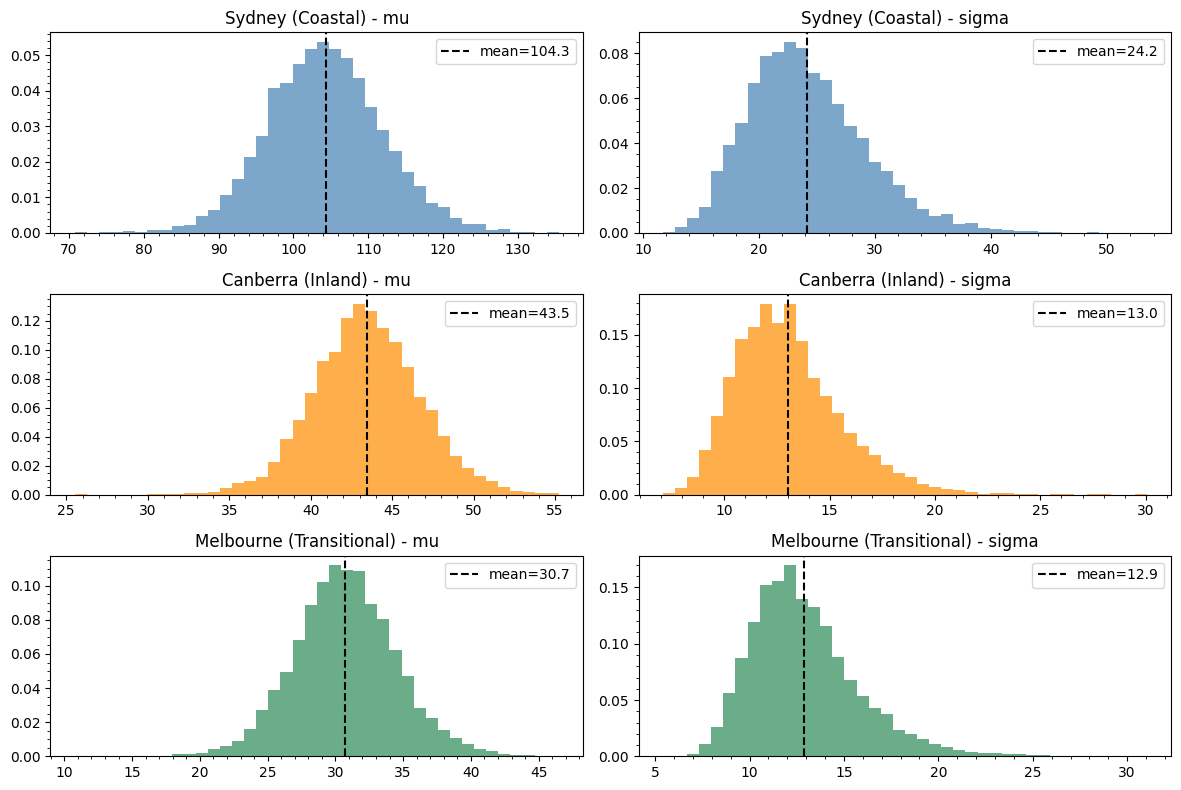

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for i, (trace, name) in enumerate(zip(
    [trace_syd, trace_can, trace_mel],
    ['Sydney (Coastal)', 'Canberra (Inland)', 'Melbourne (Transitional)']
)):
    for j, param in enumerate(['mu', 'sigma']):
        samples = trace.posterior[param].values.flatten()
        axes[i, j].hist(samples, bins=40, density=True,
                        color=['steelblue','darkorange','seagreen'][i],
                        alpha=0.7)
        axes[i, j].axvline(samples.mean(), color='black',
                           linestyle='--', lw=1.5,
                           label=f'mean={samples.mean():.1f}')
        axes[i, j].set_title(f'{name} - {param}')
        axes[i, j].legend()
        axes[i, j].minorticks_on()

plt.tight_layout()
plt.show()

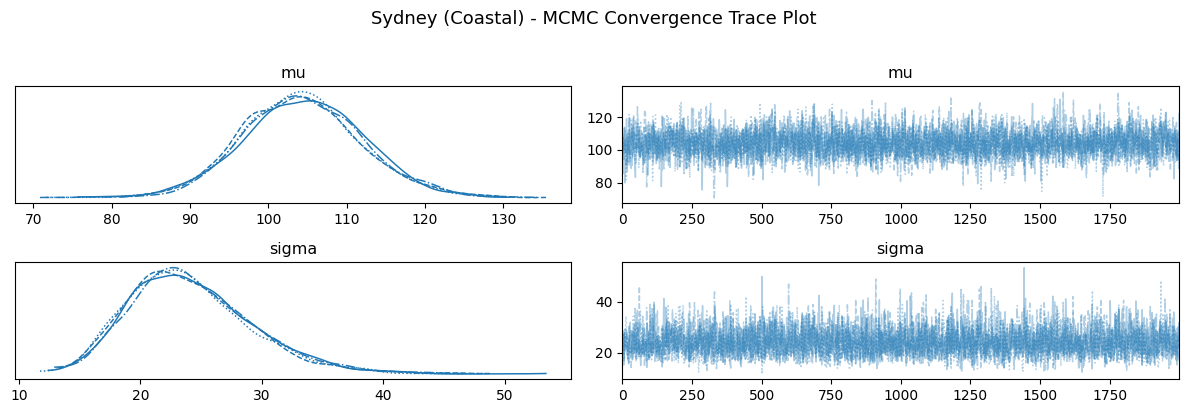

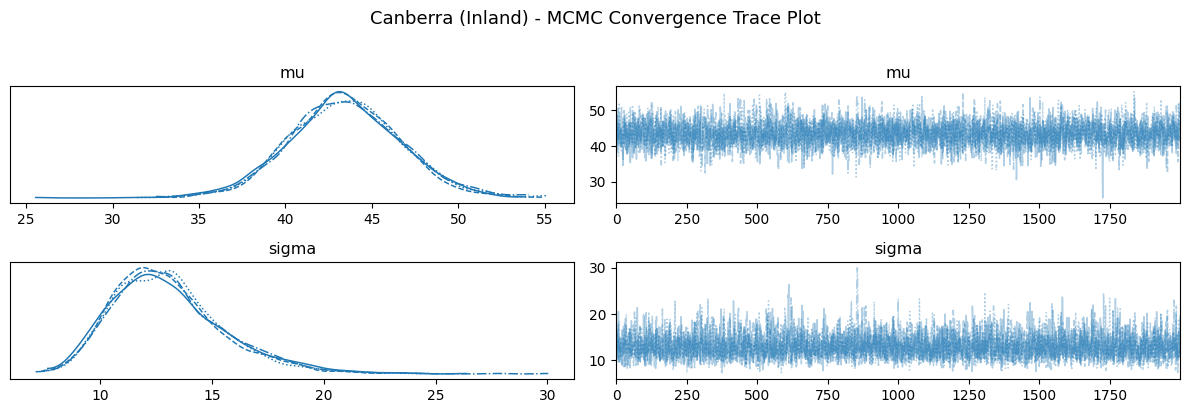

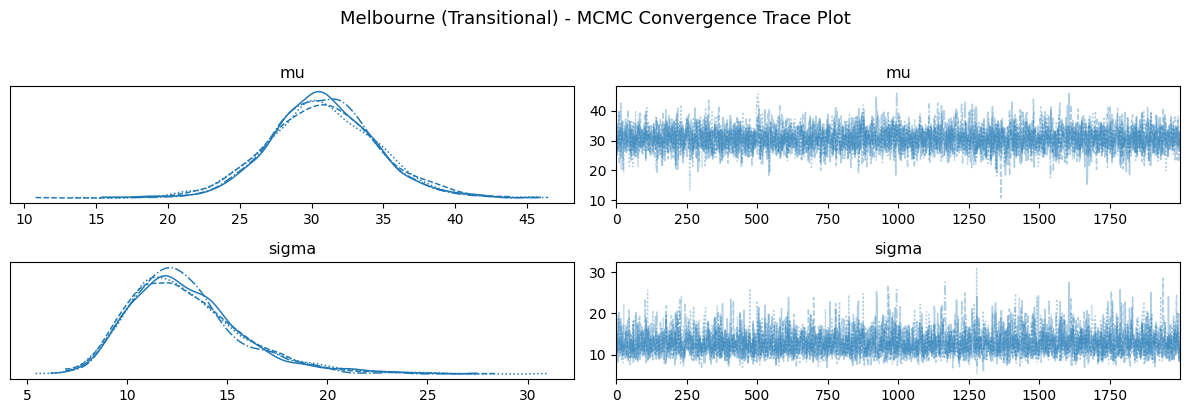

In [11]:
for trace, name in zip(
    [trace_syd, trace_can, trace_mel],
    ['Sydney (Coastal)', 'Canberra (Inland)', 'Melbourne (Transitional)']
):
    az.plot_trace(trace, var_names=['mu', 'sigma'])
    plt.suptitle(f'{name} - MCMC Convergence Trace Plot',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

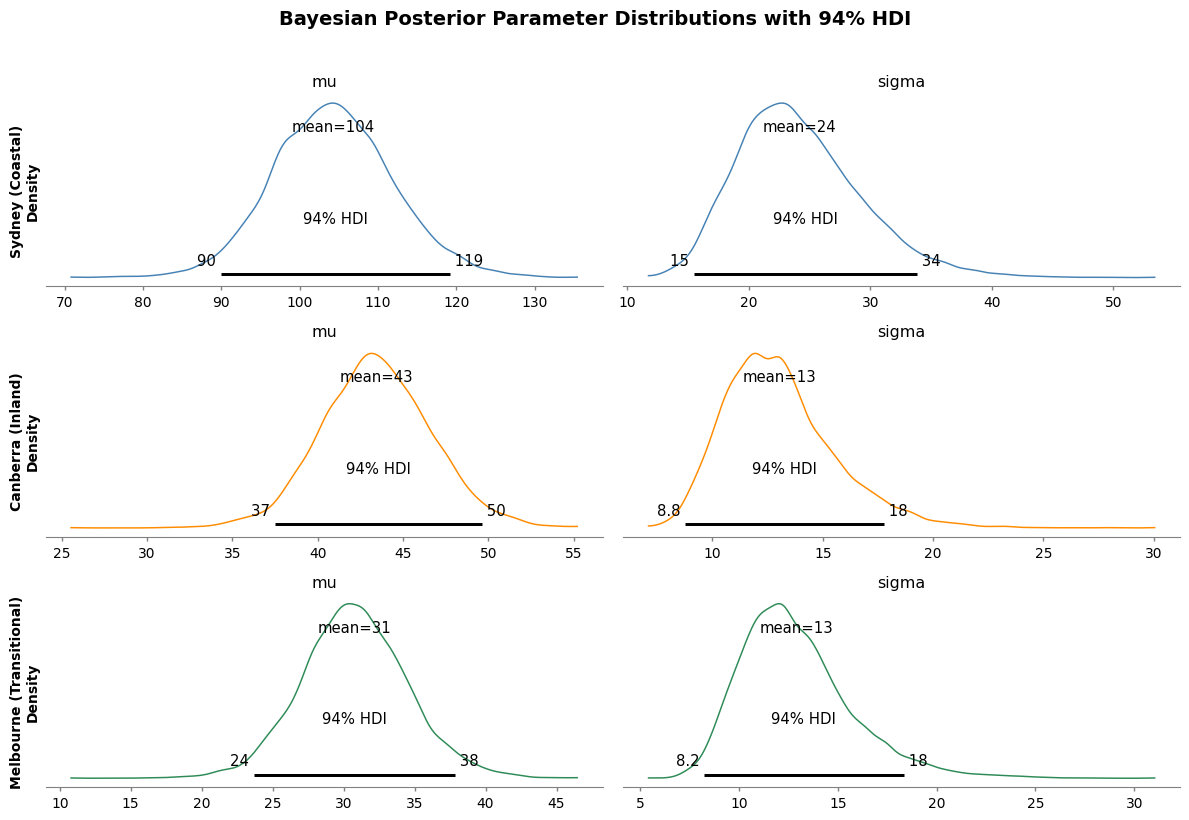

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

traces_list   = [trace_syd, trace_can, trace_mel]
station_names = ['Sydney (Coastal)', 'Canberra (Inland)', 'Melbourne (Transitional)']
colors        = ['steelblue', 'darkorange', 'seagreen']

for i, (trace, name, color) in enumerate(zip(traces_list, station_names, colors)):
    az.plot_posterior(
        trace,
        var_names=['mu', 'sigma'],
        ax=axes[i, :],
        color=color,
        point_estimate='mean',
        hdi_prob=0.94,
        textsize=10
    )
    axes[i, 0].set_ylabel(f'{name}\nDensity', fontsize=10, fontweight='bold')

plt.suptitle('Bayesian Posterior Parameter Distributions with 94% HDI',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The Bayesian model returned the following posterior estimates:

| Station | Posterior μ (mean) | 94% HDI μ | Posterior σ (mean) | 94% HDI σ |
|---------|-------------------|-----------|-------------------|-----------|
| Sydney (Coastal) | 104.3 mm | [90, 119] | 24.2 mm | [15, 34] |
| Canberra (Inland) | 43.5 mm | [37, 50] | 13.0 mm | [8.8, 18] |
| Melbourne (Transitional) | 30.7 mm | [24, 38] | 12.9 mm | [8.2, 18] |

The posterior distributions quantify our uncertainty about the
true Gumbel parameters given the observed data. Sydney's notably
wider HDI for μ ([90, 119] mm — a range of ~29 mm) compared to
Canberra ([37, 50] mm — a range of ~13 mm) reflects both
Sydney's greater year-to-year rainfall variability and its
relatively short record length in this dataset.

The posterior means are broadly consistent with the MLE estimates
from Section 3, which validates the model. The slight differences
arise because the Bayesian approach incorporates prior information
and propagates uncertainty through the full posterior distribution
rather than returning a single point estimate.

In [13]:
def exceedance_probability(trace, threshold, station_name):
    mu_samples    = trace.posterior['mu'].values.flatten()
    sigma_samples = trace.posterior['sigma'].values.flatten()

    probs = [1 - stats.gumbel_r.cdf(threshold, loc=mu, scale=sigma)
             for mu, sigma in zip(mu_samples, sigma_samples)]
    probs = np.array(probs)

    print(f"\n{station_name} - P(rainfall > {threshold} mm):")
    print(f"  Posterior mean: {probs.mean():.4f}")
    print(f"  95% HDI:        [{np.percentile(probs, 2.5):.4f}, "
          f"{np.percentile(probs, 97.5):.4f}]")
    return probs

probs_syd = exceedance_probability(trace_syd, 100, 'Sydney')
probs_can = exceedance_probability(trace_can, 100, 'Canberra')
probs_mel = exceedance_probability(trace_mel, 100, 'Melbourne')


Sydney - P(rainfall > 100 mm):
  Posterior mean: 0.6891
  95% HDI:        [0.4594, 0.8778]

Canberra - P(rainfall > 100 mm):
  Posterior mean: 0.0160
  95% HDI:        [0.0016, 0.0571]

Melbourne - P(rainfall > 100 mm):
  Posterior mean: 0.0072
  95% HDI:        [0.0002, 0.0352]


P(Annual Max Rainfall > 100 mm)

| Station | Posterior Mean P(>100mm) | 95% HDI |
|---------|--------------------------|---------|
| Sydney (Coastal) | **0.6891** | [0.4594, 0.8778] |
| Canberra (Inland) | 0.0160 | [0.0016, 0.0571] |
| Melbourne (Transitional) | 0.0072 | [0.0002, 0.0352] |

Sydney has a strikingly high exceedance probability of **0.69**,
meaning that in any given year, there is approximately a **69%
chance** that the daily rainfall maximum will exceed 100 mm.
This reflects Sydney's coastal location and exposure to intense
East Coast Low events capable of delivering very heavy rainfall
in short periods.

By contrast, Canberra and Melbourne have exceedance probabilities
of only **1.6%** and **0.7%** respectively, reflecting their
inland and frontal rainfall regimes which rarely produce
single-day totals of this magnitude.

The wide credible intervals — particularly for Canberra
([0.0016, 0.0571]) and Melbourne ([0.0002, 0.0352]) — reflect
genuine uncertainty arising from the short record lengths
available at these stations.


In [14]:
def return_period(trace, level, station_name):
    mu_samples    = trace.posterior['mu'].values.flatten()
    sigma_samples = trace.posterior['sigma'].values.flatten()

    periods = [1 / (1 - stats.gumbel_r.cdf(level, loc=mu, scale=sigma))
               for mu, sigma in zip(mu_samples, sigma_samples)]
    periods = np.array(periods)

    print(f"\n{station_name} - Return Period for {level} mm:")
    print(f"  Posterior mean: {periods.mean():.1f} years")
    print(f"  95% HDI:        [{np.percentile(periods, 2.5):.1f}, "
          f"{np.percentile(periods, 97.5):.1f}] years")
    return periods

return_period(trace_syd, 150, 'Sydney')
return_period(trace_can, 150, 'Canberra')
return_period(trace_mel, 150, 'Melbourne')


Sydney - Return Period for 150 mm:
  Posterior mean: 9.6 years
  95% HDI:        [3.2, 28.8] years

Canberra - Return Period for 150 mm:
  Posterior mean: 24574.2 years
  95% HDI:        [249.7, 156646.5] years

Melbourne - Return Period for 150 mm:
  Posterior mean: 1410480.2 years
  95% HDI:        [361.3, 1358657.7] years


array([  4459.59960218,  45826.56915764,   6397.4774625 , ...,
       332299.14598883, 332299.14598883, 171034.03882269])

Return Period for 150 mm Events

| Station | Posterior Mean Return Period | 95% HDI |
|---------|------------------------------|---------|
| Sydney (Coastal) | **9.6 years** | [3.2, 28.8] years |
| Canberra (Inland) | ~24,574 years | [249.7, 156,646] years |
| Melbourne (Transitional) | ~1,410,480 years | [361, 1,358,657] years |

For Sydney, a 150 mm daily rainfall event has an estimated return
period of approximately **10 years**, meaning such an event is
expected roughly once per decade. This is consistent with
historical observations of extreme rainfall associated with
East Coast Lows.

For Canberra and Melbourne, the return periods are astronomically
large, indicating that a 150 mm single-day event is essentially
outside the range of plausible observations under current climate
conditions at these inland and transitional stations. The
extremely wide credible intervals for these stations reflect
the high sensitivity of tail estimates to parameter uncertainty
when extrapolating far beyond the range of observed data —
a known limitation of extreme value analysis with short records.

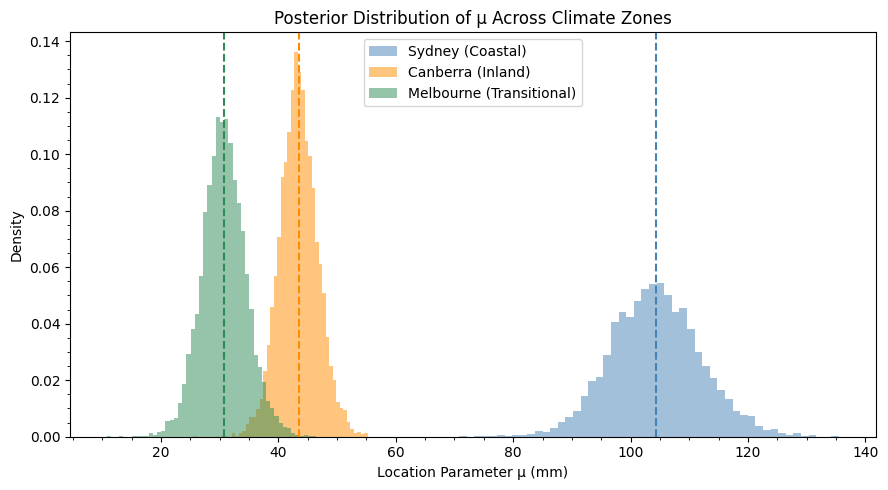

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

for trace, name, color in zip(
    [trace_syd, trace_can, trace_mel],
    ['Sydney (Coastal)', 'Canberra (Inland)', 'Melbourne (Transitional)'],
    ['steelblue', 'darkorange', 'seagreen']
):
    mu_samples = trace.posterior['mu'].values.flatten()
    ax.hist(mu_samples, bins=50, density=True,
            alpha=0.5, color=color, label=name)
    ax.axvline(mu_samples.mean(), color=color, linestyle='--', lw=1.5)

ax.set_xlabel('Location Parameter μ (mm)')
ax.set_ylabel('Density')
ax.set_title('Posterior Distribution of μ Across Climate Zones')
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

Posterior μ Comparison

The posterior distributions of μ across the three stations are
clearly separated with minimal overlap, confirming that the
differences in extreme rainfall behaviour between climate zones
are statistically robust and not simply due to sampling uncertainty.

Sydney's posterior (μ = 104 mm) is entirely separate from those
of Canberra (μ = 43 mm) and Melbourne (μ = 31 mm), which
themselves show some overlap. This pattern is consistent with
the known climate geography of south-eastern Australia: coastal
stations are exposed to moisture-laden maritime air masses and
synoptic-scale storm systems capable of producing extreme
one-day totals, while inland and transitional stations experience
lower-intensity precipitation regimes.



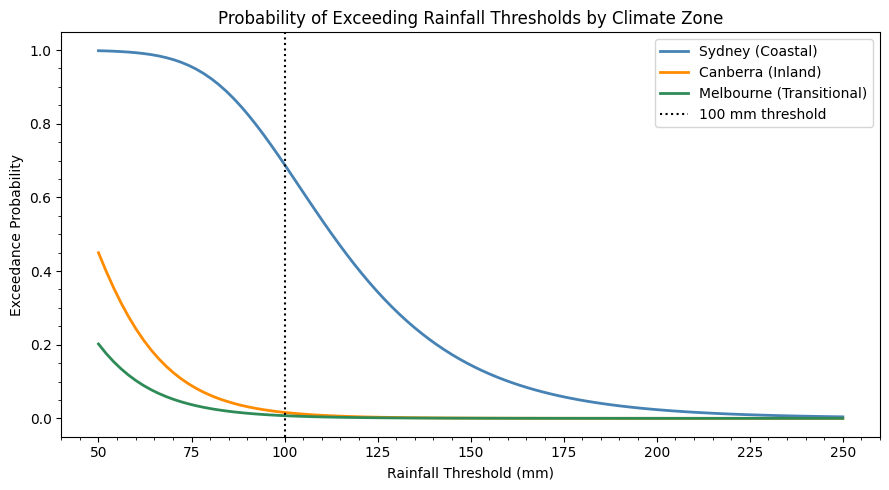

In [16]:
thresholds = np.linspace(50, 250, 100)
fig, ax = plt.subplots(figsize=(9, 5))

for trace, name, color in zip(
    [trace_syd, trace_can, trace_mel],
    ['Sydney (Coastal)', 'Canberra (Inland)', 'Melbourne (Transitional)'],
    ['steelblue', 'darkorange', 'seagreen']
):
    mu_samples    = trace.posterior['mu'].values.flatten()
    sigma_samples = trace.posterior['sigma'].values.flatten()

    mean_probs = [
        np.mean([1 - stats.gumbel_r.cdf(t, loc=mu, scale=sigma)
                 for mu, sigma in zip(mu_samples, sigma_samples)])
        for t in thresholds
    ]
    ax.plot(thresholds, mean_probs, color=color, lw=2, label=name)

ax.axvline(100, color='black', linestyle=':', lw=1.5,
           label='100 mm threshold')
ax.set_xlabel('Rainfall Threshold (mm)')
ax.set_ylabel('Exceedance Probability')
ax.set_title('Probability of Exceeding Rainfall Thresholds by Climate Zone')
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

Exceedance Probability Curves

The exceedance probability curves reinforce this contrast.
Sydney's curve remains substantially above zero across the entire
50–250 mm range, while Canberra and Melbourne drop to near-zero
probability beyond approximately 80–90 mm. At the 100 mm
threshold, Sydney's exceedance probability (about 0.69) is over
40 times greater than Canberra's (about 0.016) and nearly 100 times
greater than Melbourne's (about 0.007).


In [17]:
results = []

for trace, name in zip(
    [trace_syd, trace_can, trace_mel],
    ['Sydney', 'Canberra', 'Melbourne']
):
    mu_samples    = trace.posterior['mu'].values.flatten()
    sigma_samples = trace.posterior['sigma'].values.flatten()

    probs_100  = [1 - stats.gumbel_r.cdf(100, loc=mu, scale=sigma)
                  for mu, sigma in zip(mu_samples, sigma_samples)]
    periods_150 = [1 / (1 - stats.gumbel_r.cdf(150, loc=mu, scale=sigma))
                   for mu, sigma in zip(mu_samples, sigma_samples)]

    results.append({
        'Station':             name,
        'Posterior μ (mm)':    round(mu_samples.mean(), 1),
        'Posterior σ (mm)':    round(sigma_samples.mean(), 1),
        'P(>100mm)':           round(np.mean(probs_100), 3),
        'Return Period 150mm': round(np.mean(periods_150), 1)
    })

print(pd.DataFrame(results).to_string(index=False))

  Station  Posterior μ (mm)  Posterior σ (mm)  P(>100mm)  Return Period 150mm
   Sydney             104.3              24.2      0.689                  9.6
 Canberra              43.5              13.0      0.016              24574.2
Melbourne              30.7              12.9      0.007            1410480.2


Final Summary

| Station | Posterior μ | Posterior σ | P(>100mm) | Return Period 150mm |
|---------|-------------|-------------|-----------|---------------------|
| Sydney (Coastal) | 104.3 mm | 24.2 mm | 0.689 | ~10 years |
| Canberra (Inland) | 43.5 mm | 13.0 mm | 0.016 | ~24,574 years |
| Melbourne (Transitional) | 30.7 mm | 12.9 mm | 0.007 | ~1,410,480 years |



###Conclusions

This analysis demonstrates that **extreme daily rainfall risk
differs dramatically across climate zones in south-eastern
Australia**. The coastal station (Sydney) faces substantially
higher extreme rainfall risk than either the inland (Canberra)
or transitional (Melbourne) stations, with a ~69% annual
probability of exceeding 100 mm and an estimated 10-year
return period for 150 mm events.

The Bayesian framework proved valuable in two key ways. First,
it produced full posterior distributions for all parameters
rather than single point estimates, making the uncertainty in
extreme event probabilities explicit. Second, the wide credible
intervals for Canberra and Melbourne honestly communicate
that tail estimates for rare events are highly uncertain when
based on short observational records — a crucial caveat for
any practical application.

The Gumbel distribution consistently provided a better fit
to the observed data than the Normal distribution across all
three stations, validating the theoretical basis of Extreme
Value Theory for block maxima data.